In [ ]:
!pip install librosa pandas numpy tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/Shareddrives/CS 163 Project/VocalSet.zip" -d "/content/"

Archive:  /content/drive/Shareddrives/CS 163 Project/VocalSet.zip
   creating: /content/FULL/
  inflating: /content/FULL/.DS_Store  
   creating: /content/__MACOSX/
   creating: /content/__MACOSX/FULL/
  inflating: /content/__MACOSX/FULL/._.DS_Store  
   creating: /content/FULL/female9/
  inflating: /content/FULL/female9/.DS_Store  
   creating: /content/__MACOSX/FULL/female9/
  inflating: /content/__MACOSX/FULL/female9/._.DS_Store  
   creating: /content/FULL/female9/excerpts/
   creating: /content/FULL/female9/excerpts/vibrato/
  inflating: /content/FULL/female9/excerpts/vibrato/f9_caro_vibrato.wav  
  inflating: /content/FULL/female9/excerpts/vibrato/f9_row_vibrato.wav  
  inflating: /content/FULL/female9/excerpts/vibrato/f9_dona_vibrato.wav  
   creating: /content/FULL/female9/excerpts/straight/
  inflating: /content/FULL/female9/excerpts/straight/f9_dona_straight.wav  
  inflating: /content/FULL/female9/excerpts/straight/f9_row_straight.wav  
  inflating: /content/FULL/female9/exc

In [ ]:
import glob

# Collect all .wav audio file paths inside the VocalSet dataset directory
files = glob.glob("/content/FULL/**/*.wav", recursive=True)

print("Total wav files:", len(files))
print(files[:10])

Total wav files: 3613
['/content/FULL/male1/excerpts/spoken/m1_row_spoken.wav', '/content/FULL/male1/excerpts/vibrato/m1_dona_vibrato.wav', '/content/FULL/male1/excerpts/vibrato/m1_caro_vibrato.wav', '/content/FULL/male1/excerpts/vibrato/m1_row_vibrato.wav', '/content/FULL/male1/excerpts/straight/m1_caro_straight.wav', '/content/FULL/male1/excerpts/straight/m1_dona_straight.wav', '/content/FULL/male1/excerpts/straight/m1_row_straight.wav', '/content/FULL/male1/long_tones/pp/m1_long_pp_u.wav', '/content/FULL/male1/long_tones/pp/m1_long_pp_i.wav', '/content/FULL/male1/long_tones/pp/m1_long_pp_o.wav']


In [ ]:
# Filter the file list to ensure only .wav audio files are included
# (this helps avoid hidden files like .DS_Store that may appear in the dataset)
files = [f for f in files if f.lower().endswith(".wav")]
import pandas as pd
# Extract the vocal technique label from the directory structure
# The technique is the folder name before the file (e.g., belt, breathy, vibrato)
tech = pd.Series([f.split("/")[-2] for f in files], name="technique")
tech.value_counts()

,count
technique,
slow_piano,397
slow_forte,395
fast_forte,394
fast_piano,386
straight,361
vibrato,255
belt,205
lip_trill,202
breathy,200


belt -> high energy
breathy -> low energy

In [ ]:
# Create an empty list to store only the audio files we want to keep
filtered_files = []
for f in files:
     # Extract the vocal technique from the folder name
    # The technique is the directory before the filename
    technique = f.split("/")[-2]

    # Keep only the ones with the vocal technique we want
    if technique == "belt" or technique == "breathy":
        filtered_files.append(f)

# Replace the original file list with the filtered subset
files = filtered_files

# Create a pandas Series of the remaining techniques
# This helps confirm that only belt and breathy remain in the dataset
tech_filtered = pd.Series([f.split("/")[-2] for f in files], name="technique")
display(tech_filtered.value_counts())

,count
technique,
belt,205
breathy,200


In [ ]:
!pip -q install librosa tqdm praat-parselmouth

import numpy as np
import librosa
from tqdm import tqdm
import parselmouth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 79.8 MB/s eta 0:00:00


In [ ]:
# Function to estimate the fundamental frequency (pitch) of an audio signal
# using the YIN algorithm provided by librosa
def compute_f0_yin(y, sr, fmin=50, fmax=500):

    # Compute pitch values across the audio signal
    # fmin and fmax define the expected pitch range for human vocals
    f0 = librosa.yin(y, fmin=fmin, fmax=fmax, sr=sr)

    # Remove any invalid pitch values (NaN or infinite values)
    f0 = f0[np.isfinite(f0)]

    # Return the average pitch across the audio clip
    # If no valid values exist, return NaN
    return float(np.mean(f0)) if len(f0) else np.nan

# Function to compute the Harmonic-to-Noise Ratio (HNR) using Praat via parselmouth
# HNR measures how harmonic (clean) versus noisy a voice signal is
def compute_hnr_praat(file_path, min_pitch=50):

    # Load the audio file using parselmouth (Praat interface)
    snd = parselmouth.Sound(file_path)

    # Compute harmonicity values across the signal
    harm = snd.to_harmonicity_cc(time_step=0.01, minimum_pitch=min_pitch)

    # Extract the harmonicity values
    vals = harm.values[0]

    # Remove invalid values
    vals = vals[np.isfinite(vals)]

    # Return the mean HNR value for the audio clip
    return float(np.mean(vals)) if len(vals) else np.nan


# Function to extract all acoustic features from a single audio file
def extract_features(file_path):

    # Load the audio file using librosa
    # sr=None keeps the original sampling rate of the file
    # mono=True converts stereo audio into a single channel
    y, sr = librosa.load(file_path, sr=None, mono=True)

    # Compute the fundamental frequency (pitch)
    f0 = compute_f0_yin(y, sr)

    # Compute the spectral centroid
    # This represents the "brightness" of the sound
    centroid = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))

    # Compute the spectral rolloff
    # This indicates the frequency below which most spectral energy lies
    rolloff = float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)))

    # Compute the harmonic-to-noise ratio (voice clarity vs noise)
    # This uses Praat through parselmouth
    hnr = compute_hnr_praat(file_path)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_means = np.mean(mfcc, axis=1)  # shape (13,)

    return f0, centroid, rolloff, hnr, mfcc_means



In [ ]:
# Initialize an empty list to store the extracted feature data
rows = []

# Counter to track files that fail during feature extraction
failed = 0

# Loop through every audio file in the filtered dataset
# tqdm displays a progress bar so we can track extraction progress
for i, fp in enumerate(tqdm(files)):
    try:
        # Extract the vocal technique from the folder name in the file path
        # This will be either "belt" or "breathy"
        technique = fp.split("/")[-2]

        # Map the technique to the corresponding class label
        # belt → high energy vocals
        # breathy → low energy vocals
        if technique == "belt":
            label = "high_energy"
        else:
            label = "low_energy"

        # Extract acoustic features from the audio file
        # Returns pitch (f0), spectral centroid, spectral rolloff, and HNR
        f0, centroid, rolloff, hnr, mfcc_means = extract_features(fp)

        # Store the extracted features and metadata in a dictionary
        rows.append({
            "sample_id": i,
            "file_path": fp,
            "technique": technique,
            "class": label,
            "f0": f0,
            "spectral_centroid": centroid,
            "spectral_rolloff": rolloff,
            "hnr": hnr,
        **{f"mfcc_{i}": v for i, v in enumerate(mfcc_means)}
        })

    # If an error occurs during feature extraction (e.g., corrupted audio file),
    # increment the failure counter and skip that file
    except Exception:
        failed += 1

# Convert the collected rows into a pandas DataFrame for analysis
df = pd.DataFrame(rows)

# Display how many files were successfully processed
print("Extracted rows:", df.shape[0])

# Display how many files failed during feature extraction
print("Failed files:", failed)

# Show the first few rows of the dataset to verify the extracted features
df.head()

100%|██████████| 405/405 [10:15<00:00,  1.52s/it]

Extracted rows: 405
Failed files: 0


,sample_id,file_path,technique,class,f0,spectral_centroid,spectral_rolloff,hnr,mfcc_0,mfcc_1,...,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
0,0,/content/FULL/male1/scales/breathy/m1_scales_b...,breathy,low_energy,193.101146,4230.890064,8838.712498,-6.152726,-701.201538,71.597572,...,35.178734,79.752220,33.413597,-3.784929,-19.673222,9.669172,-8.696858,-7.166232,-8.480966,-3.168283
1,1,/content/FULL/male1/scales/breathy/m1_scales_b...,breathy,low_energy,199.695008,2985.598138,6527.255004,23.766282,-664.838440,126.050064,...,11.980864,16.115732,-27.916710,-6.866961,-2.208933,38.313896,-8.756350,-10.283900,5.345440,4.655121
2,2,/content/FULL/male1/scales/breathy/m1_scales_b...,breathy,low_energy,193.957287,4053.986754,10172.026478,4.661040,-740.664612,109.781265,...,27.318871,30.239058,-24.102224,2.140531,-15.712206,26.937712,0.988805,0.697227,4.346208,3.717593
3,3,/content/FULL/male1/scales/breathy/m1_scales_b...,breathy,low_energy,197.405641,3984.860696,9006.308695,2.027973,-649.168152,95.293549,...,19.854464,48.387352,25.567915,-1.444940,-26.590565,3.722243,-14.002104,3.988909,7.543588,-2.341362
4,4,/content/FULL/male1/scales/breathy/m1_scales_b...,breathy,low_energy,197.049524,3894.397740,5713.720703,-15.699670,-737.602112,105.237076,...,29.756308,34.677814,-7.032602,8.846575,-8.403748,16.716595,4.100768,9.286543,-5.535470,0.261549


In [ ]:
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Basic validity filters (safe defaults)
df = df[(df["f0"] > 50) & (df["f0"] < 500)]
df = df[(df["spectral_centroid"] > 0) & (df["spectral_rolloff"] > 0)]

print(df.shape)
print(df["class"].value_counts())
print(df.groupby("class").mean(numeric_only=True))
df.describe()

(405, 21)
class
high_energy    205
low_energy     200
Name: count, dtype: int64
              sample_id          f0  spectral_centroid  spectral_rolloff  \
class                                                                      
high_energy  205.658537  245.917628        3124.064844       5398.233422   
low_energy   198.250000  252.360847        3193.747154       6319.907019   

                  hnr      mfcc_0      mfcc_1     mfcc_2     mfcc_3  \
class                                                                 
high_energy -5.926238 -401.706329   98.947258 -49.122932  10.386837   
low_energy  -8.311923 -550.543640  106.626434  17.505453  11.931408   

                mfcc_4    mfcc_5     mfcc_6    mfcc_7    mfcc_8     mfcc_9  \
class                                                                        
high_energy   6.016963 -3.162432 -28.398890 -4.299579  4.900394 -13.675113   
low_energy   10.163509  1.083787  -7.182915 -5.978450  5.668426  -7.338940   

               mf

,sample_id,f0,spectral_centroid,spectral_rolloff,hnr,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
count,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000
mean,202.000000,249.099464,3158.475861,5853.380877,-7.104354,-475.206207,102.739449,-16.220024,11.149588,8.064640,-1.065534,-17.921865,-5.128651,5.279669,-10.546139,-8.117312,0.137649,-3.796352
std,117.057678,71.337303,788.739949,2289.375966,14.711259,103.715225,35.896721,44.253006,22.334431,27.340122,24.767448,18.004454,21.139381,15.259288,13.186263,11.437457,12.799919,9.155863
min,0.000000,158.326740,1420.762795,1634.101230,-86.201807,-795.439514,13.300976,-102.732430,-51.260910,-42.610489,-57.151665,-70.648186,-57.076057,-37.680885,-45.695599,-38.493290,-38.905106,-38.734829
25%,101.000000,177.893369,2565.909322,4430.523476,-13.111713,-545.856140,78.602432,-53.243027,-4.456522,-14.142547,-18.858887,-32.210670,-22.552738,-5.874755,-21.675201,-16.524137,-8.407248,-9.436005
50%,202.000000,208.100950,3044.766479,5352.753679,-3.952880,-469.670441,101.988235,-16.974798,10.421831,5.108503,-4.432789,-17.229820,-4.935583,4.944155,-10.374322,-8.095042,-1.943651,-3.969836
75%,303.000000,318.655896,3590.667159,6649.531191,2.084921,-400.114563,134.248611,14.583279,25.552881,26.805334,14.062878,-4.193588,10.821438,15.715379,-1.023655,-0.526251,8.794346,2.374082
max,404.000000,367.749826,6613.677655,17127.241109,23.766282,-260.508209,171.901901,103.913887,78.997063,87.474075,72.796974,29.936390,49.964737,44.542412,23.513287,20.710058,37.214294,26.026052


In [ ]:
out_path = "/content/drive/Shareddrives/CS 163 Project/vocal_features.csv"
df.to_csv(out_path, index=False)
print("Saved to:", out_path)

Saved to: /content/drive/Shareddrives/CS 163 Project/vocal_features.csv


In [ ]:
# Load completed feature CSV — run this cell to skip re-running feature extraction
import pandas as pd
import numpy as np

CSV_PATH = '/content/drive/Shareddrives/CS 163 Project/vocal_features.csv'
df = pd.read_csv(CSV_PATH)

print('Loaded:', df.shape)
print(df['technique'].value_counts())
df.head()

Loaded: (405, 21)
technique
belt       205
breathy    200
Name: count, dtype: int64


,sample_id,file_path,technique,class,f0,spectral_centroid,spectral_rolloff,hnr,mfcc_0,mfcc_1,...,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
0,0,/content/FULL/male1/scales/breathy/m1_scales_b...,breathy,low_energy,193.101146,4230.890064,8838.712498,-6.152726,-701.20154,71.597570,...,35.178734,79.752220,33.413597,-3.784929,-19.673222,9.669172,-8.696858,-7.166232,-8.480966,-3.168283
1,1,/content/FULL/male1/scales/breathy/m1_scales_b...,breathy,low_energy,199.695008,2985.598138,6527.255004,23.766282,-664.83844,126.050064,...,11.980864,16.115732,-27.916710,-6.866962,-2.208933,38.313896,-8.756350,-10.283900,5.345440,4.655121
2,2,/content/FULL/male1/scales/breathy/m1_scales_b...,breathy,low_energy,193.957287,4053.986754,10172.026478,4.661040,-740.66460,109.781265,...,27.318870,30.239058,-24.102224,2.140531,-15.712206,26.937712,0.988805,0.697227,4.346208,3.717593
3,3,/content/FULL/male1/scales/breathy/m1_scales_b...,breathy,low_energy,197.405641,3984.860696,9006.308695,2.027973,-649.16815,95.293550,...,19.854464,48.387352,25.567915,-1.444940,-26.590565,3.722243,-14.002104,3.988909,7.543588,-2.341362
4,4,/content/FULL/male1/scales/breathy/m1_scales_b...,breathy,low_energy,197.049524,3894.397740,5713.720703,-15.699670,-737.60210,105.237076,...,29.756308,34.677814,-7.032602,8.846575,-8.403748,16.716595,4.100768,9.286543,-5.535470,0.261549


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DRIVE_PATH = '/content/drive/Shareddrives/CS 163 Project/'
COLORS = {'belt': '#2196F3', 'breathy': '#FF9800'}
FEATURES = ['f0', 'spectral_centroid', 'spectral_rolloff', 'hnr'] + [f'mfcc_{i}' for i in range(13)]
LABELS = {
    'f0': 'f0 (Hz)',
    'spectral_centroid': 'Spectral Centroid (Hz)',
    'spectral_rolloff': 'Spectral Rolloff (Hz)',
    'hnr': 'HNR (dB)'
}
print('EDA setup complete.')

EDA setup complete.


In [ ]:
# Data quality check
print('=== MISSING VALUES ===')
print(df[FEATURES].isnull().sum())

print('\n=== DUPLICATE ROWS ===')
print(f'Duplicates: {df.duplicated().sum()}')

print('\n=== HNR RANGE ===')
print(f'Min: {df["hnr"].min():.2f} dB | Max: {df["hnr"].max():.2f} dB')

hnr_outliers = df[df['hnr'] < -20]
print(f'\nHNR outliers (< -20 dB): {len(hnr_outliers)} rows')
print(hnr_outliers['technique'].value_counts())

=== MISSING VALUES ===
f0                   0
spectral_centroid    0
spectral_rolloff     0
hnr                  0
mfcc_0               0
mfcc_1               0
mfcc_2               0
mfcc_3               0
mfcc_4               0
mfcc_5               0
mfcc_6               0
mfcc_7               0
mfcc_8               0
mfcc_9               0
mfcc_10              0
mfcc_11              0
mfcc_12              0
dtype: int64

=== DUPLICATE ROWS ===
Duplicates: 0

=== HNR RANGE ===
Min: -86.20 dB | Max: 23.77 dB

HNR outliers (< -20 dB): 56 rows
technique
breathy    35
belt       21
Name: count, dtype: int64


In [ ]:
# Filter HNR artifacts before computing stats
df_clean = df[df['hnr'] >= -20].copy()
removed = len(df) - len(df_clean)
print(f'Rows removed: {removed} ({removed/len(df)*100:.1f}%)')
print(f'Clean dataset: {df_clean.shape}')
print(df_clean['technique'].value_counts())

Rows removed: 56 (13.8%)
Clean dataset: (349, 21)
technique
belt       184
breathy    165
Name: count, dtype: int64


In [ ]:
# Overall descriptive statistics
print('=== OVERALL DESCRIPTIVE STATS ===')
print(df_clean[FEATURES].describe().round(3).to_string())

=== OVERALL DESCRIPTIVE STATS ===
            f0  spectral_centroid  spectral_rolloff      hnr   mfcc_0   mfcc_1   mfcc_2   mfcc_3   mfcc_4   mfcc_5   mfcc_6   mfcc_7   mfcc_8   mfcc_9  mfcc_10  mfcc_11  mfcc_12
count  349.000            349.000           349.000  349.000  349.000  349.000  349.000  349.000  349.000  349.000  349.000  349.000  349.000  349.000  349.000  349.000  349.000
mean   245.284           3095.083          5741.023   -2.762 -468.370  105.034  -18.691   10.908    8.452   -0.519  -18.206   -5.567    5.209  -10.191   -8.391    0.264   -3.866
std     71.042            749.906          2235.837    8.357  104.521   35.957   44.266   22.756   27.662   25.459   18.203   21.647   15.567   13.152   11.830   13.240    9.100
min    158.327           1420.763          1634.101  -19.713 -775.628   13.301 -102.732  -51.261  -42.610  -57.152  -70.648  -57.076  -37.681  -45.696  -38.493  -38.905  -38.735
25%    177.833           2552.408          4415.394   -8.814 -538.700   79.4

In [ ]:
# Per-class descriptive statistics (belt vs. breathy)
print('=== PER-CLASS STATS ===\n')
for technique in ['belt', 'breathy']:
    print(f'--- {technique.upper()} ---')
    subset = df_clean[df_clean['technique'] == technique][FEATURES]
    print(subset.describe().round(3).to_string())
    print()

=== PER-CLASS STATS ===

--- BELT ---
            f0  spectral_centroid  spectral_rolloff      hnr   mfcc_0   mfcc_1   mfcc_2   mfcc_3   mfcc_4   mfcc_5   mfcc_6   mfcc_7   mfcc_8   mfcc_9  mfcc_10  mfcc_11  mfcc_12
count  184.000            184.000           184.000  184.000  184.000  184.000  184.000  184.000  184.000  184.000  184.000  184.000  184.000  184.000  184.000  184.000  184.000
mean   244.039           3071.138          5323.706   -2.574 -395.959  101.139  -50.516    9.651    5.258   -3.079  -28.356   -3.777    4.634  -13.378  -11.604    2.313   -5.877
std     68.448            590.122          1110.565    7.290   59.982   39.742   25.863   25.402   28.489   27.314   14.951   23.990   16.886   13.278   12.815   14.612    9.925
min    162.848           1869.102          3429.094  -18.959 -549.001   13.301 -102.732  -51.261  -41.375  -49.254  -70.648  -57.076  -32.736  -45.696  -38.493  -38.905  -38.735
25%    178.096           2620.227          4503.315   -7.280 -436.207   

In [ ]:
# Correlation matrix
corr = df_clean[FEATURES].corr().round(3)
print('=== CORRELATION MATRIX ===')
print(corr.to_string())

=== CORRELATION MATRIX ===
                      f0  spectral_centroid  spectral_rolloff    hnr  mfcc_0  mfcc_1  mfcc_2  mfcc_3  mfcc_4  mfcc_5  mfcc_6  mfcc_7  mfcc_8  mfcc_9  mfcc_10  mfcc_11  mfcc_12
f0                 1.000              0.473             0.455  0.009  -0.117  -0.752  -0.022  -0.113  -0.416  -0.351   0.071   0.542  -0.372  -0.433    0.173    0.120   -0.156
spectral_centroid  0.473              1.000             0.891 -0.328  -0.301  -0.680  -0.027   0.073   0.107   0.010   0.066   0.191  -0.250  -0.315    0.191    0.046   -0.071
spectral_rolloff   0.455              0.891             1.000 -0.219  -0.400  -0.565   0.177   0.080   0.048  -0.035   0.154   0.201  -0.192  -0.272    0.175    0.026    0.026
hnr                0.009             -0.328            -0.219  1.000  -0.104   0.116   0.119   0.009   0.004  -0.073   0.083  -0.031   0.106  -0.093   -0.141    0.042   -0.078
mfcc_0            -0.117             -0.301            -0.400 -0.104   1.000   0.033  -0.841 

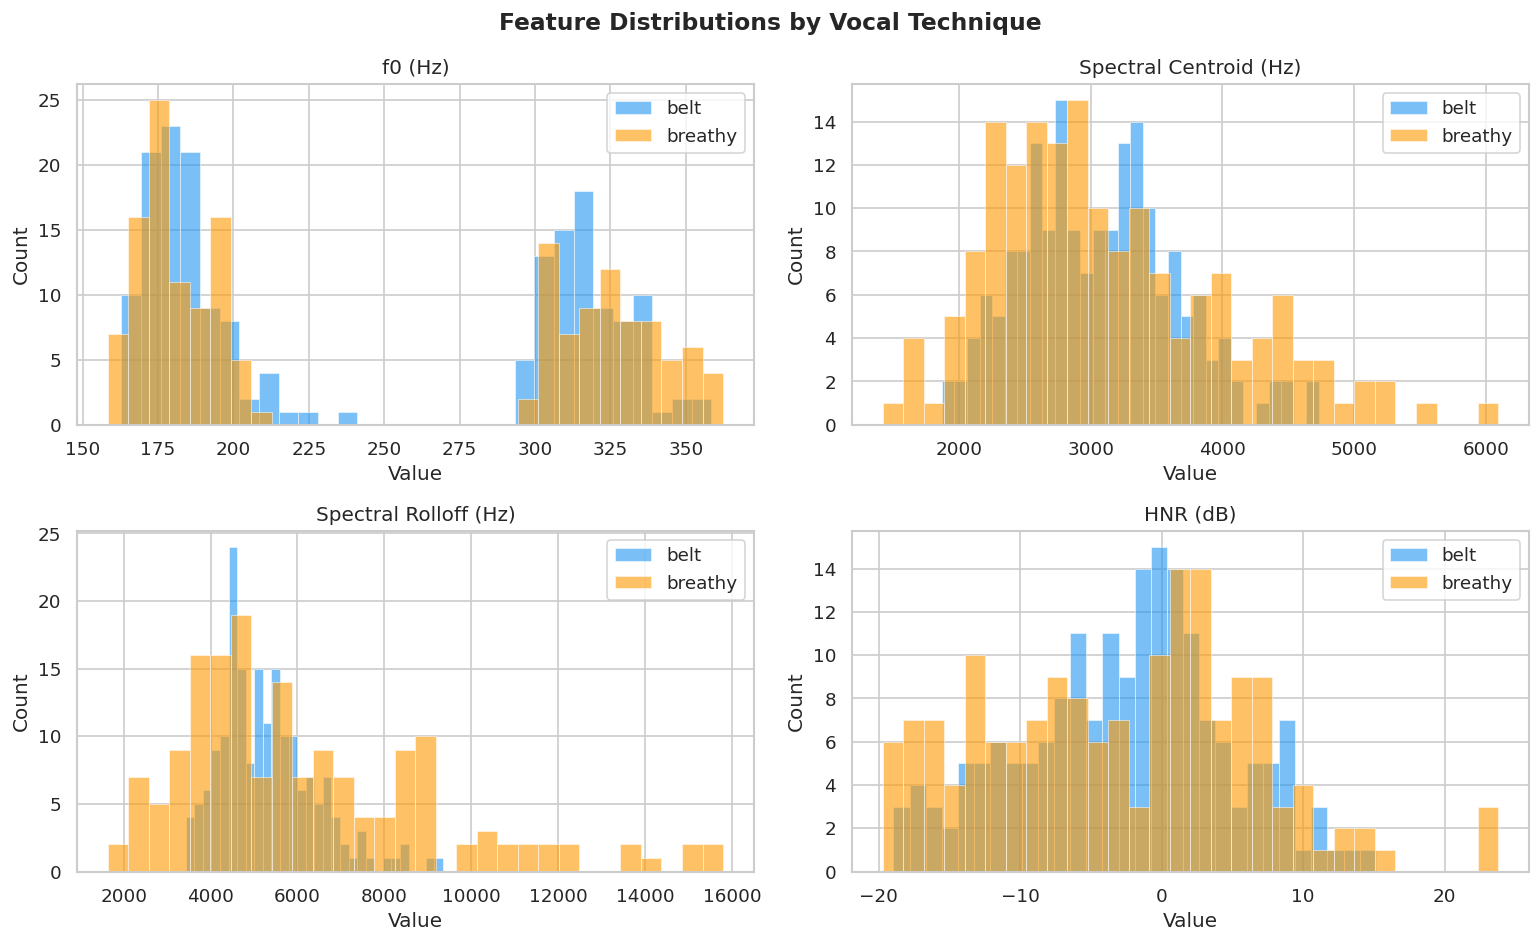

Saved: eda_hist_features.png


In [ ]:
# Histograms — feature distributions overlaid by class
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Feature Distributions by Vocal Technique', fontsize=14, fontweight='bold')

for ax, feature in zip(axes.flatten(), FEATURES):
    for technique, color in COLORS.items():
        vals = df_clean[df_clean['technique'] == technique][feature]
        ax.hist(vals, bins=30, alpha=0.6, color=color, label=technique,
                edgecolor='white', linewidth=0.5)
    ax.set_title(LABELS[feature])
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'eda_hist_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_hist_features.png')

/tmp/ipykernel_586/2645769166.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='technique', y=feature, ax=ax,
/tmp/ipykernel_586/2645769166.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='technique', y=feature, ax=ax,
/tmp/ipykernel_586/2645769166.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='technique', y=feature, ax=ax,
/tmp/ipykernel_586/2645769166.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

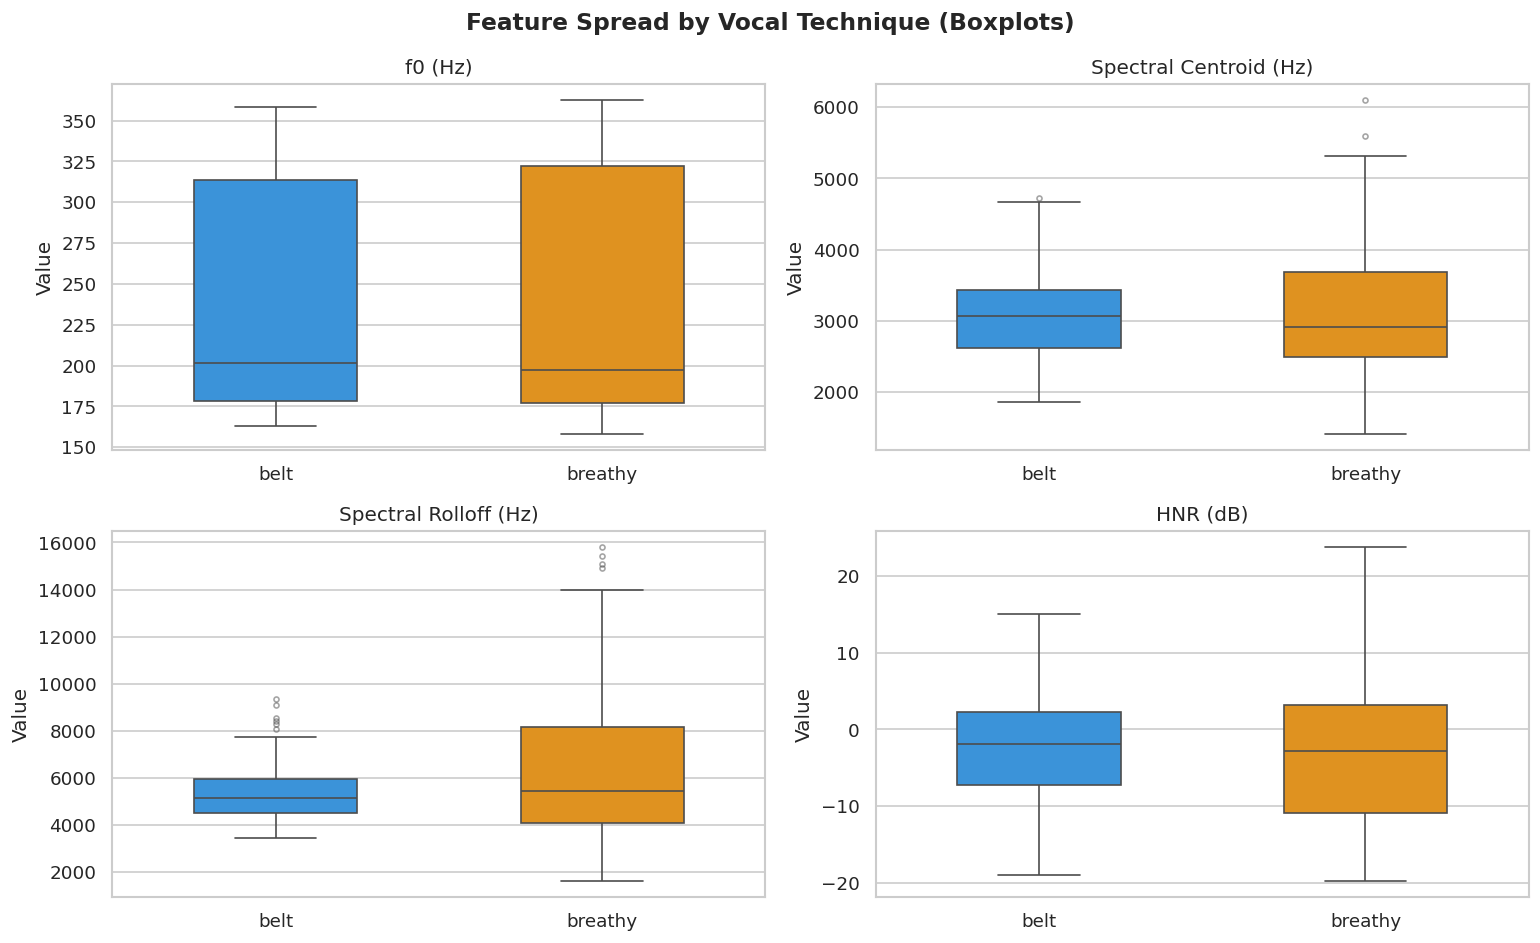

Saved: eda_boxplot_features.png


In [ ]:
# Boxplots — feature spread by class
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Feature Spread by Vocal Technique (Boxplots)', fontsize=14, fontweight='bold')

for ax, feature in zip(axes.flatten(), FEATURES):
    sns.boxplot(data=df_clean, x='technique', y=feature, ax=ax,
                palette=COLORS, order=['belt', 'breathy'],
                width=0.5, flierprops=dict(marker='o', markersize=3, alpha=0.5))
    ax.set_title(LABELS[feature])
    ax.set_xlabel('')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'eda_boxplot_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_boxplot_features.png')

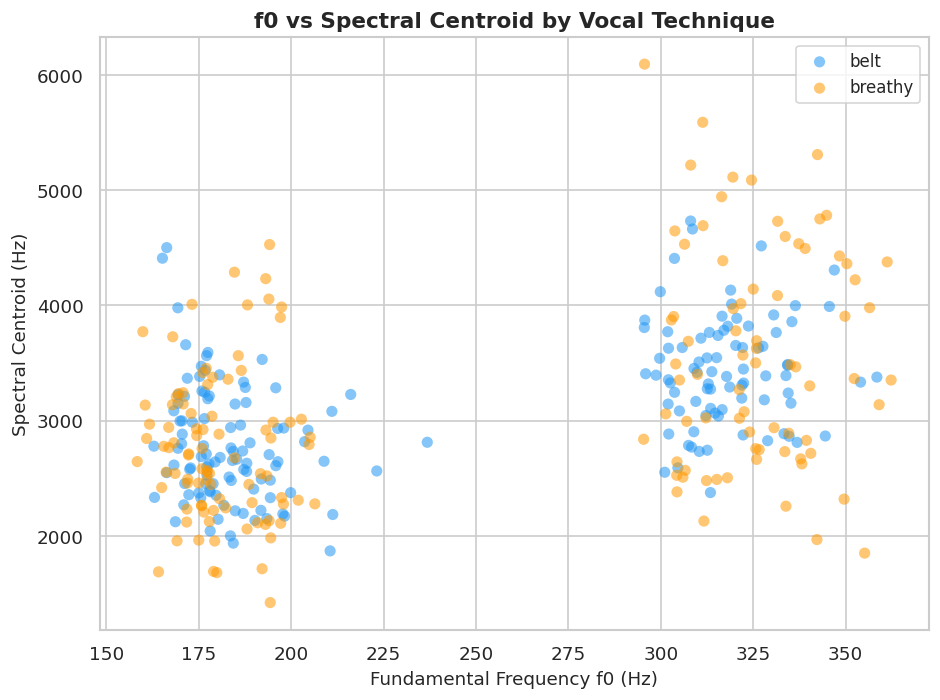

Saved: eda_scatter_f0_centroid.png


In [ ]:
# Scatter plot — f0 vs spectral centroid colored by class
fig, ax = plt.subplots(figsize=(8, 6))

for technique, color in COLORS.items():
    subset = df_clean[df_clean['technique'] == technique]
    ax.scatter(subset['f0'], subset['spectral_centroid'],
               alpha=0.55, color=color, label=technique, s=45, edgecolors='none')

ax.set_xlabel('Fundamental Frequency f0 (Hz)', fontsize=11)
ax.set_ylabel('Spectral Centroid (Hz)', fontsize=11)
ax.set_title('f0 vs Spectral Centroid by Vocal Technique', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'eda_scatter_f0_centroid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_scatter_f0_centroid.png')

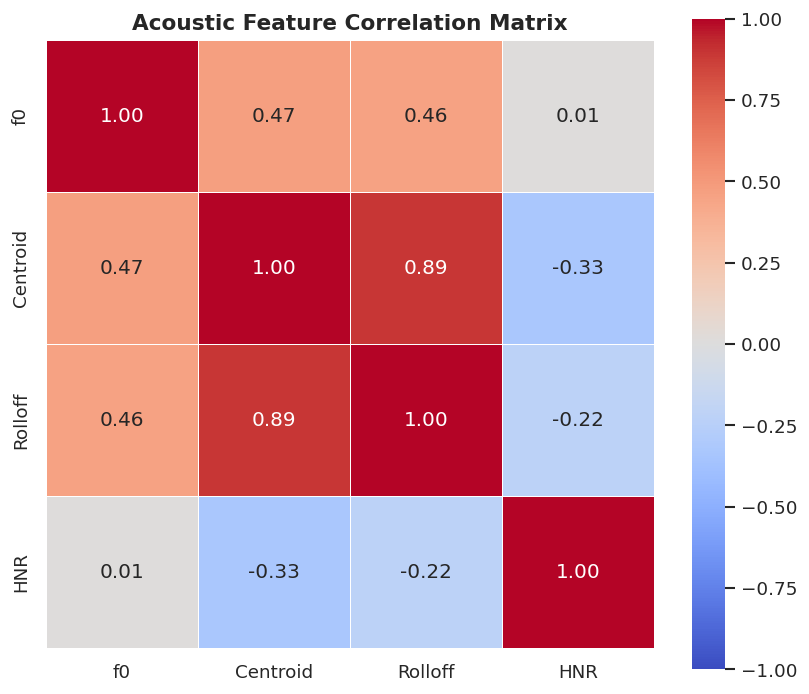

Saved: eda_heatmap_corr.png


In [ ]:
# Correlation heatmap
corr = df_clean[FEATURES].corr()
tick_labels = ['f0', 'Centroid', 'Rolloff', 'HNR']

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=tick_labels, yticklabels=tick_labels,
            square=True, linewidths=0.5)
ax.set_title('Acoustic Feature Correlation Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'eda_heatmap_corr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_heatmap_corr.png')

## Preliminary Insights

| Hypothesis | Feature(s) | What to look for |
|------------|-----------|------------------|
| Belt has higher pitch | f0 | Belt median f0 > Breathy median f0 |
| Belt has brighter timbre | spectral_centroid, spectral_rolloff | Belt values higher |
| Belt is more periodic | hnr | Belt HNR > Breathy HNR |
| Centroid and rolloff correlate | both | Strong positive correlation expected |

**HNR note:** Values below -20 dB were filtered as extraction artifacts.  
If removal was class-skewed, note it as a data quality limitation in the report.

In [ ]:
!pip -q install xgboost shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


In [ ]:
# prepare data
X = df_clean[FEATURES]
y = df_clean["class"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(y.value_counts())

class
high_energy    184
low_energy     165
Name: count, dtype: int64


In [ ]:
# Logistic Regression

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9285714285714286
              precision    recall  f1-score   support

 high_energy       0.94      0.92      0.93        37
  low_energy       0.91      0.94      0.93        33

    accuracy                           0.93        70
   macro avg       0.93      0.93      0.93        70
weighted avg       0.93      0.93      0.93        70



In [ ]:
# Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("Cross-val scores:", scores)
print("Mean:", scores.mean())

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Cross-val scores: [0.95714286 0.98571429 0.94285714 0.92857143 0.86956522]
Mean: 0.9367701863354039
Random Forest Accuracy: 0.9
              precision    recall  f1-score   support

 high_energy       0.94      0.86      0.90        37
  low_energy       0.86      0.94      0.90        33

    accuracy                           0.90        70
   macro avg       0.90      0.90      0.90        70
weighted avg       0.90      0.90      0.90        70



In [ ]:
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train_xgb)

y_pred_xgb = xgb.predict(X_test)
y_pred_xgb_labels = le.inverse_transform(y_pred_xgb)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb_labels))
print(classification_report(y_test, y_pred_xgb_labels))

XGBoost Accuracy: 0.8857142857142857
              precision    recall  f1-score   support

 high_energy       0.91      0.86      0.89        37
  low_energy       0.86      0.91      0.88        33

    accuracy                           0.89        70
   macro avg       0.89      0.89      0.89        70
weighted avg       0.89      0.89      0.89        70



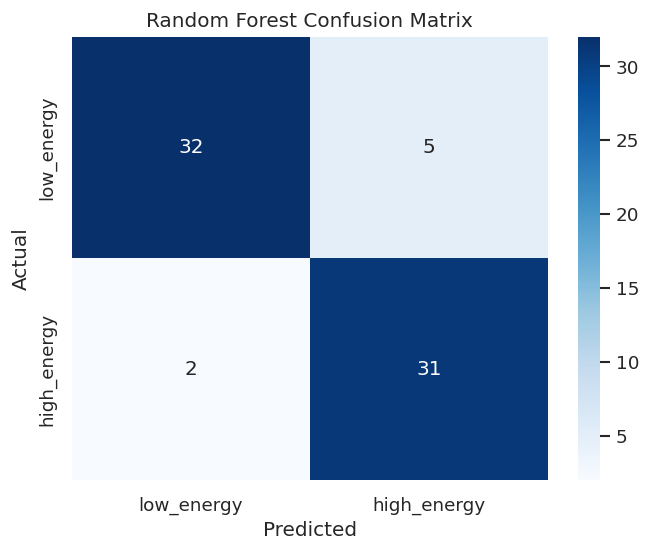

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["low_energy", "high_energy"],
            yticklabels=["low_energy", "high_energy"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

              feature  importance
6              mfcc_2    0.325204
4              mfcc_0    0.203851
10             mfcc_6    0.125695
16            mfcc_12    0.060661
13             mfcc_9    0.040680
14            mfcc_10    0.038938
2    spectral_rolloff    0.038904
5              mfcc_1    0.022662
7              mfcc_3    0.021673
9              mfcc_5    0.019171
8              mfcc_4    0.018781
11             mfcc_7    0.016835
12             mfcc_8    0.016240
15            mfcc_11    0.015749
3                 hnr    0.012314
0                  f0    0.011896
1   spectral_centroid    0.010746


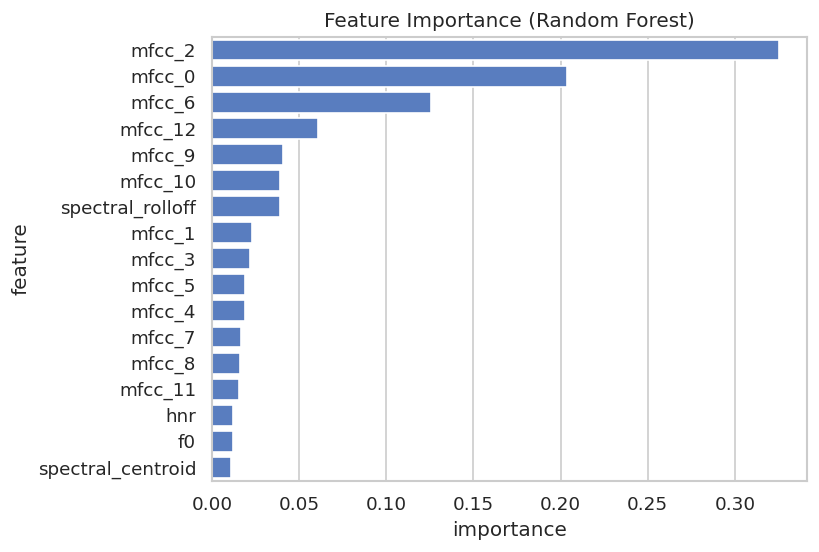

In [ ]:
importances = pd.DataFrame({
    "feature": FEATURES,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(importances)

sns.barplot(data=importances, x="importance", y="feature")
plt.title("Feature Importance (Random Forest)")
plt.show()

In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.9285714285714286
Random Forest Accuracy: 0.9


Explained variance ratio: [0.23331133 0.17108679]
Total explained variance: 0.4043981187567898


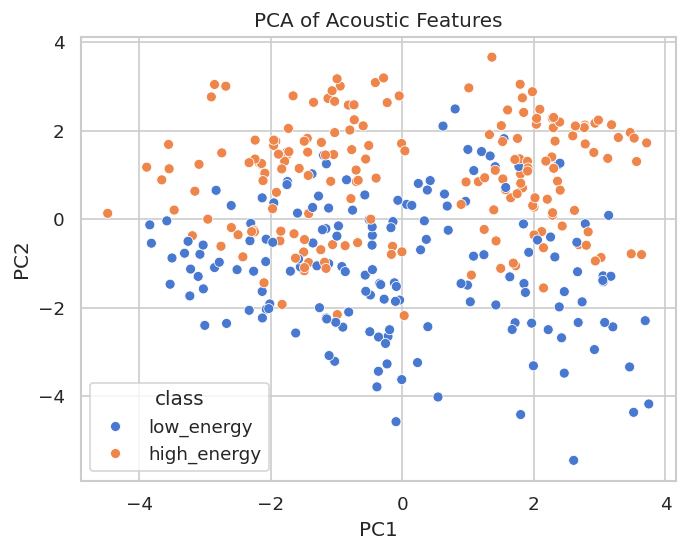

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "class": y.values
})

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="class")
plt.title("PCA of Acoustic Features")
plt.show()

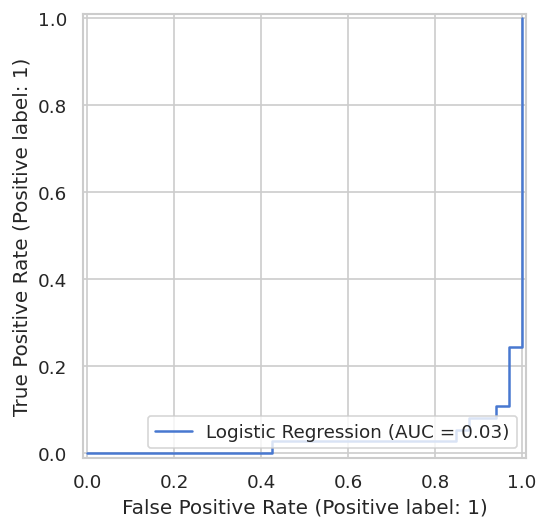

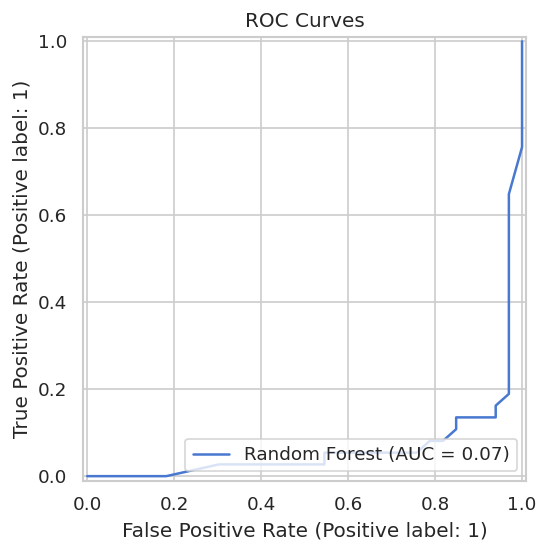

In [ ]:
from sklearn.metrics import RocCurveDisplay

y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

y_test_bin = (y_test == "high_energy").astype(int)

RocCurveDisplay.from_predictions(y_test_bin, y_prob_lr, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test_bin, y_prob_rf, name="Random Forest")
plt.title("ROC Curves")
plt.show()

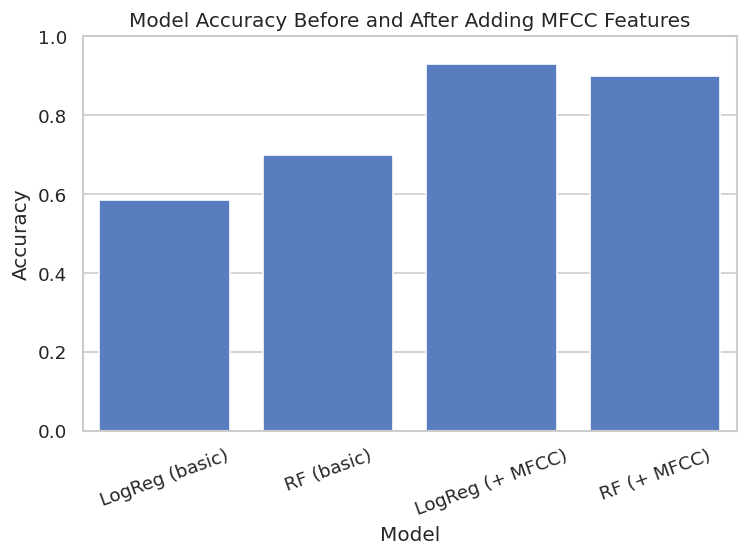

In [ ]:
results = pd.DataFrame({
    "Model": [
        "LogReg (basic)",
        "RF (basic)",
        "LogReg (+ MFCC)",
        "RF (+ MFCC)"
    ],
    "Accuracy": [
        0.5857,
        0.7000,
        0.9286,
        0.9000
    ]
})

sns.barplot(data=results, x="Model", y="Accuracy")
plt.ylim(0, 1)
plt.title("Model Accuracy Before and After Adding MFCC Features")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()